week6 lab

In [10]:
%pip install shap 

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 11.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   --------------------

In [ ]:
from datetime import datetime, timedelta

import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import odc.stac
import pandas as pd
import pystac_client
import rioxarray  # noqa: F401
import shap
import xarray as xr
from dask.distributed import Client
from odc.geo.geobox import GeoBox
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler

client = Client(processes=False)

2026-02-19 13:51:31,655 - distributed.scheduler - WARNING - Worker failed to heartbeat for 5282s; removing: <WorkerState 'inproc://10.102.225.98/36916/4', name: 0, status: running, memory: 0, processing: 0>
2026-02-19 13:51:31,693 - distributed.scheduler - WARNING - Workers ['inproc://10.102.225.98/36916/4'] do not use a nanny and will be terminated without restarting them
2026-02-19 13:51:31,715 - distributed.scheduler - WARNING - Received heartbeat from unregistered worker 'inproc://10.102.225.98/36916/4'.
2026-02-19 13:51:31,869 - distributed.worker - WARNING - Scheduler was unaware of this worker; shutting down.


Part 1: Data Aquisiton, Preprocessing, and Feature Engineering

In [12]:
# Load all available Sentinel-2 bands for initial analysis
ALL_BANDS = [
    "scl",
    "red",
    "green",
    "blue",
    "nir",
    "swir16",
    "swir22",
    "rededge1",
    "rededge2",
    "rededge3",
]
dx = 0.0006  # ~60m resolution
epsg = 4326

vienna_bounds = (16.32, 47.86, 16.9, 48.407)

start_date = datetime(year=2020, month=3, day=1)
end_date = start_date + timedelta(days=30)
date_query = f"{start_date.strftime('%Y-%m-%d')}/{end_date.strftime('%Y-%m-%d')}"

stac_client = pystac_client.Client.open("https://earth-search.aws.element84.com/v1")

vienna_items = stac_client.search(
    bbox=vienna_bounds,
    collections=["sentinel-2-l2a"],
    datetime=date_query,
    query={"eo:cloud_cover": {"lt": 50}},
    limit=100,
).item_collection()

print(f"Vienna: {len(vienna_items)} scenes found")

vienna_geobox = GeoBox.from_bbox(vienna_bounds, crs=f"epsg:{epsg}", resolution=dx)

dc_vienna = odc.stac.load(
    vienna_items,
    bands=ALL_BANDS,
    chunks={"time": 5, "x": 600, "y": 600},
    geobox=vienna_geobox,
    resampling="bilinear",
)
dc_vienna

Vienna: 19 scenes found


<xarray.Dataset> Size: 285MB
Dimensions:      (latitude: 913, longitude: 967, time: 17)
Coordinates:
  * latitude     (latitude) float64 7kB 48.41 48.41 48.41 ... 47.86 47.86 47.86
  * longitude    (longitude) float64 8kB 16.32 16.32 16.32 ... 16.9 16.9 16.9
  * time         (time) datetime64[ns] 136B 2020-03-08T09:57:16.896000 ... 20...
    spatial_ref  int32 4B 4326
Data variables:
    scl          (time, latitude, longitude) uint8 15MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    red          (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    green        (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    blue         (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    nir          (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    swir16       (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    swir22       (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    rededge1     (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    rededge2     (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>
    rededge3     (time, latitude, longitude) uint16 30MB dask.array<chunksize=(5, 600, 600), meta=np.ndarray>

Load the training data from vienna_samples.parquet in the repo. If you haven't worked with GeoParquet data before, this is very simple. Just use gpd.read_parquet(). 

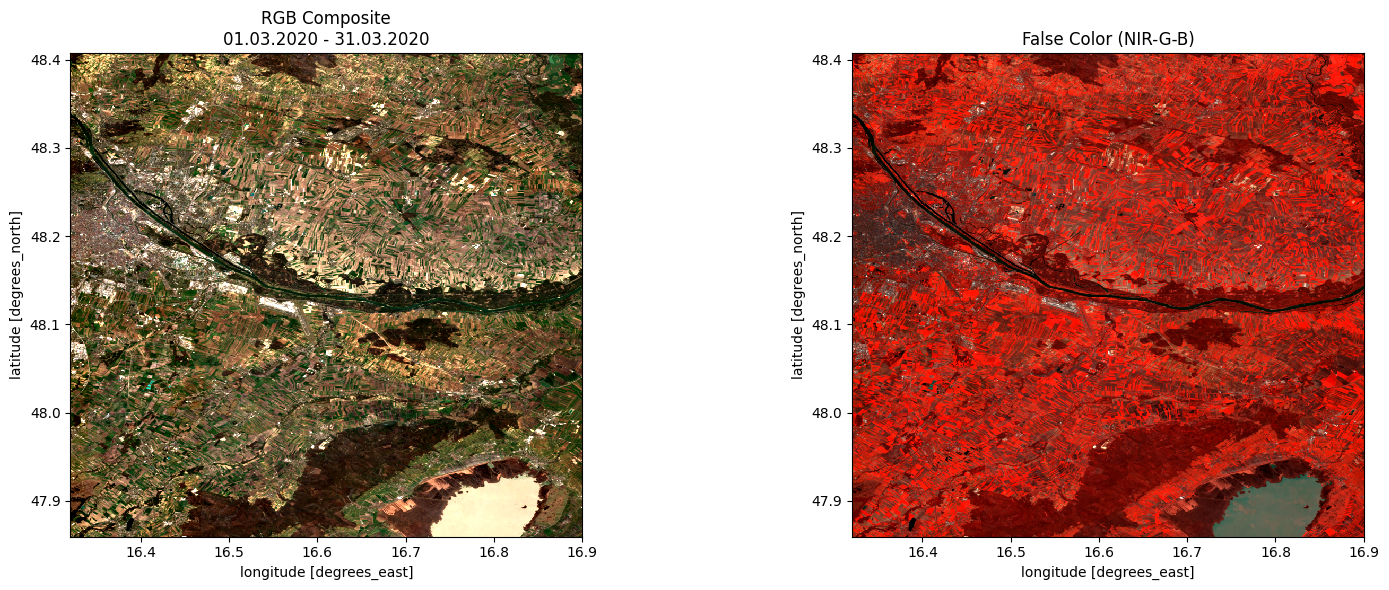

In [13]:
def is_valid_pixel(data):
    """Include vegetated, not_vegetated, water, and snow pixels (SCL classes 4-6 and 11)."""
    return ((data > 3) & (data < 7)) | (data == 11)


valid_mask = is_valid_pixel(dc_vienna.scl)
dc_valid = dc_vienna.where(valid_mask)

all_median = (
    dc_valid[["red", "green", "blue", "nir"]]
    .to_dataarray(dim="band")
    .median(dim="time")
    .compute()
)

rgb_median = all_median.sel(band=["red", "green", "blue"])
fc_median = all_median.sel(band=["nir", "green", "blue"])

fig1, axes1 = plt.subplots(1, 2, figsize=(16, 6))
rgb_median.plot.imshow(ax=axes1[0], robust=True)
axes1[0].set_title(
    f"RGB Composite\n{start_date.strftime('%d.%m.%Y')} - {end_date.strftime('%d.%m.%Y')}"
)
axes1[0].set_aspect("equal")

fc_median.plot.imshow(ax=axes1[1], robust=True)
axes1[1].set_title("False Color (NIR-G-B)")
axes1[1].set_aspect("equal")

plt.tight_layout()

In [14]:
gdf_samples = gpd.read_parquet("vienna_samples.parquet")

class_counts = gdf_samples["class_name"].value_counts()
class_pcts = (class_counts / len(gdf_samples) * 100).round(1)
class_dist = pd.DataFrame({"Count": class_counts, "Percent": class_pcts})

print(f"Total samples: {len(gdf_samples)}\n")
print("Samples per class:")
print(class_dist.to_string())

Total samples: 10000

Samples per class:
                  Count  Percent
class_name                      
Cropland           5438     54.4
Forest / shrub     1853     18.5
Urban / built-up   1496     15.0
Grassland           538      5.4
Water               414      4.1
Wetland             261      2.6


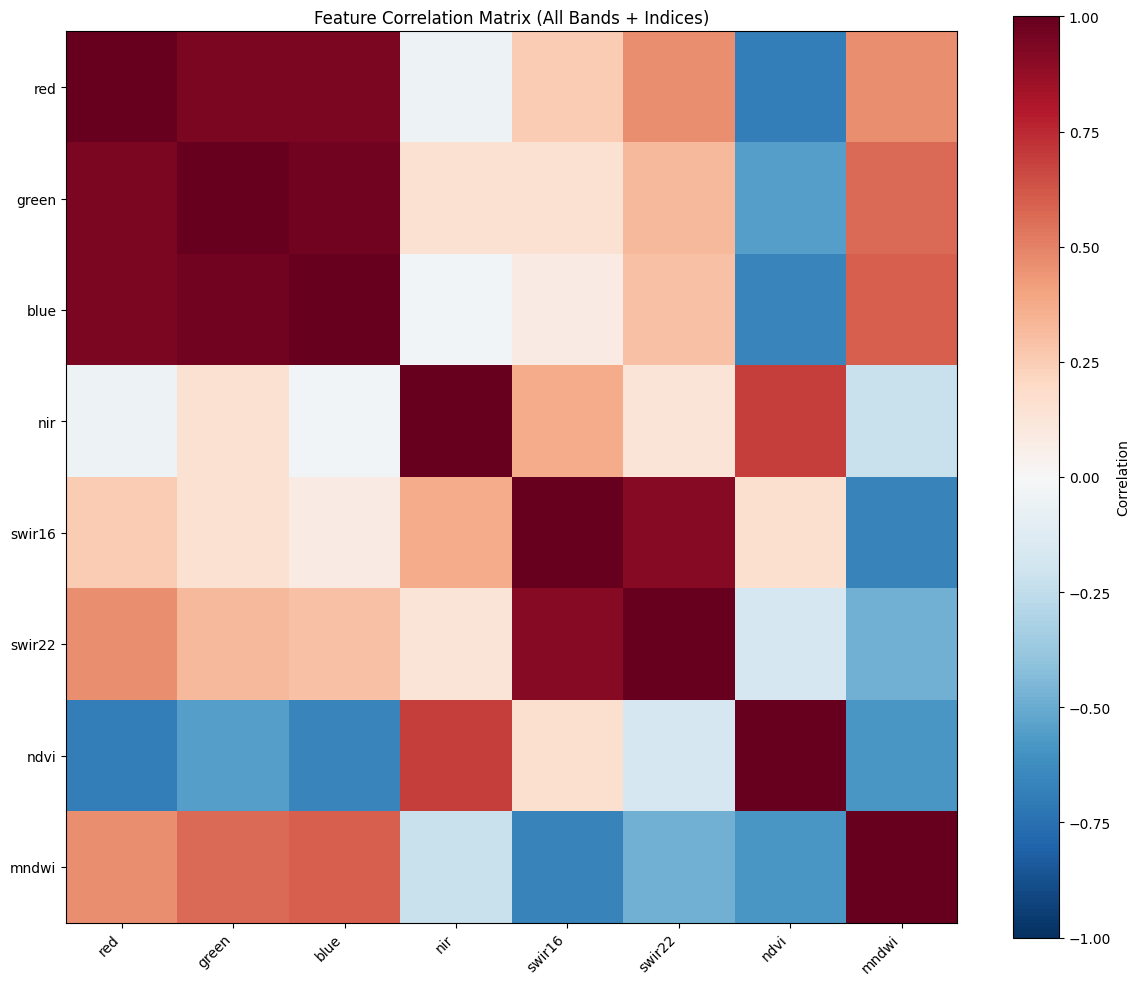

In [15]:
# All spectral bands (excluding SCL) for correlation analysis
ALL_FEATURE_BANDS = ["red", "green", "blue", "nir", "swir16", "swir22"]

# Compute median for all bands
all_bands_median = dc_valid[ALL_FEATURE_BANDS].median(dim="time").compute()

# Compute spectral indices
ndvi = (all_bands_median["nir"] - all_bands_median["red"]) / (
    all_bands_median["nir"] + all_bands_median["red"]
)
mndwi = (all_bands_median["green"] - all_bands_median["swir16"]) / (
    all_bands_median["green"] + all_bands_median["swir16"]
)

# Add indices to the dataset
all_bands_median["ndvi"] = ndvi
all_bands_median["mndwi"] = mndwi

# Full feature list including indices
ALL_FEATURES = ALL_FEATURE_BANDS + ["ndvi", "mndwi"]

# Extract all features at sample locations
X_all_bands = np.column_stack(
    [
        all_bands_median[f]
        .sel(
            longitude=xr.DataArray(gdf_samples.geometry.x.values, dims="points"),
            latitude=xr.DataArray(gdf_samples.geometry.y.values, dims="points"),
            method="nearest",
        )
        .values
        for f in ALL_FEATURES
    ]
)
y_all_raw = gdf_samples["class_id"].values

# Drop NaN samples
valid_samples_mask = ~np.isnan(X_all_bands).any(axis=1)
X_all_bands_clean = X_all_bands[valid_samples_mask]

# Correlation matrix
corr_matrix_full = np.corrcoef(X_all_bands_clean.T)
corr_df = pd.DataFrame(corr_matrix_full, index=ALL_FEATURES, columns=ALL_FEATURES)

# Plot heatmap
fig_corr_full, ax_corr_full = plt.subplots(figsize=(12, 10))
im_full = ax_corr_full.imshow(corr_matrix_full, cmap="RdBu_r", vmin=-1, vmax=1)
ax_corr_full.set_xticks(range(len(ALL_FEATURES)))
ax_corr_full.set_yticks(range(len(ALL_FEATURES)))
ax_corr_full.set_xticklabels(ALL_FEATURES, rotation=45, ha="right")
ax_corr_full.set_yticklabels(ALL_FEATURES)
plt.colorbar(im_full, ax=ax_corr_full, label="Correlation")
ax_corr_full.set_title("Feature Correlation Matrix (All Bands + Indices)")
plt.tight_layout()

In [16]:
# Selected features based on correlation analysis
FEATURE_BANDS = ["red", "green", "blue", "nir", "swir16", "swir22", "ndvi", "mndwi"]

# Extract only selected features
ds_features = all_bands_median[FEATURE_BANDS]
feature_names = FEATURE_BANDS

X_all = np.column_stack(
    [
        ds_features[f]
        .sel(
            longitude=xr.DataArray(gdf_samples.geometry.x.values, dims="points"),
            latitude=xr.DataArray(gdf_samples.geometry.y.values, dims="points"),
            method="nearest",
        )
        .values
        for f in feature_names
    ]
)[valid_samples_mask]

y_all = y_all_raw[valid_samples_mask]

Part 2

In [17]:
sample_sizes = [100, 1_000, 5_000, 10_000]
results = []

for n in sample_sizes:
    if n < len(X_all):
        X_sub, _, y_sub, _ = train_test_split(
            X_all, y_all, train_size=n, random_state=42, stratify=y_all
        )
    else:
        X_sub, y_sub = X_all, y_all

    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.3, random_state=42, stratify=y_sub
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    rf = RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train_scaled, y_train)
    y_pred = rf.predict(X_test_scaled)

    results.append(
        {
            "Samples": n,
            "Overall Acc.": accuracy_score(y_test, y_pred),
            "Macro Acc.": balanced_accuracy_score(y_test, y_pred),
            "Macro Prec.": precision_score(y_test, y_pred, average="macro"),
            "Macro Recall": recall_score(y_test, y_pred, average="macro"),
        }
    )

results_df = pd.DataFrame(results).set_index("Samples")
print(results_df.round(3).to_string())

         Overall Acc.  Macro Acc.  Macro Prec.  Macro Recall
Samples                                                     
100             0.633       0.273        0.264         0.273
1000            0.733       0.522        0.662         0.522
5000            0.793       0.635        0.813         0.635
10000           0.808       0.655        0.756         0.655
